In [676]:
import numpy as np
import scipy as sp
import time
from scipy.integrate import quad
from scipy.optimize import brentq
from scipy.optimize import root
from scipy.special import expit, logit
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation

#### Basis Functions

In [677]:
def phi_min_1(xi):
    # first basis function
    return 0.5 * xi * (xi - 1)

def phi_zero(xi):
    # first basis function
    return - xi**2 + 1

def phi_plus_1(xi):
    # first basis function
    return 0.5 * xi * (xi + 1)

def ddxi_phi_min_1(xi):
    return xi - 0.5

def ddxi_phi_zero(xi):
    return -2 * xi 

def ddxi_phi_plus_1(xi):
    return xi + 0.5

def drdxi(xi, Xe):
    """Calculates dr/d(xi) for given mesh Xe

    Args:
        xi (variable): variable of local functions
        Xe (array): array of spine-positions
        
    Returns:
        Derivative of r with respect to xi 
    """
    E1, E2, E3 = Xe
    return E1 * DPHI[0](xi) + E2 * DPHI[1](xi) + E3 * DPHI[2](xi)

PHI = [phi_min_1, phi_zero, phi_plus_1]
DPHI = [ddxi_phi_min_1, ddxi_phi_zero, ddxi_phi_plus_1]

### Node functions

In [678]:
def get_nodes(e):
    """Returns nodes covered by element e"""
    return (2 * e - 1, 2 * e, 2 * e +1)

def global_vals(e, arr):
    """ _Returns the function values at the nodes of element e_
    
    Args:
        e (int):                    element of interest
        arr (numpy array/ list):    array of values of interest at all nodes
        
    Returns:
        (tuple): values of function at nodes of element e
    """
    
    n1, n2, n3 = get_nodes(e)
    return (arr[n1-1], arr[n2-1], arr[n3-1])

#### Integrals

In [679]:
def Int_I_j(i, j, Xe):
    """_summary_

    Args:
        i (int): index of residual (between 1 and N)
        j (int): index of basis function (one of -1, 0, 1)
        Xe (3 x 1 array): array of spine-positions of nodes covered by element over which we are integrating
    """
    f = lambda xi: PHI[i](xi) * PHI[j](xi) * drdxi(xi, Xe)
    return quad(f, -1, 1)[0]

def Int_I_xi(i, j, Xe, Xe_prev, dt):
    """Returns integral I_xi

    Args:
        i (int): index of residual (between 1 and N)
        j (int): index of basis function (one of -1, 0, 1)
        Xe (3 x 1 array): array of spine-positions of nodes covered by element over which we are integrating
        Xe_prev (3 x 1 array): array of spine-positions of element spines of the element we look at at previous time step
    """
    def partial_sum(xi):
        return sum((Xe[m] - Xe_prev[m]) / dt * PHI[m](xi) for m in range(3))
    
    f = lambda xi: partial_sum(xi) * PHI[i](xi) * DPHI[j](xi)
    return quad(f, -1, 1)[0]

def Int_I_xixi(i, j, Xe):
    """Returns integral I_xixi
    
        Args:
            i (int): index of residual (between 1 and N)
            j (int): index of basis function (one of 0, 1, 2)
            Xe (3 x 1 array): array of spine-positions of nodes covered by element over which we are integrating
    """
    f = lambda xi: DPHI[i](xi) * DPHI[j](xi) * 1/np.abs(drdxi(xi, Xe))
    return quad(f, -1, 1)[0]

def Int_I(i, Xe):
    """Returns integral I_i
        
        Args:
            i (int): index of residual (between 1 and N)
            Xe (3 x 1 array): array of spine-positions of nodes covered by element over which we are integrating
    """
    f = lambda xi: PHI[i](xi) * drdxi(xi, Xe)
    return quad(f, -1, 1)[0]

### Mesh

In [680]:
def solve_omega_R(R, I_contact, O_contact):
    """Root-finding from: 1 = R + (R/(2*I_contact)) * sum_{e=1}^{2*O_contact} omega^e
    HOW DO WE KNOW THERE IS ONE ROOT?

    Args:
        R (float): contact radius, in (0, 1).
        I_contact (int): number of elements inside the contact radius.
        O_contact (int): number of elements outside the contact radius (= E - I_contact).

    Returns:
        float or None: omega, or None if O_contact == 0 (no outer region, nothing to solve).
    """
    if O_contact == 0:
        return None
    def f(omega):
        s = sum(omega ** e for e in range(1, 2 * O_contact + 1))
        return R + (R / (2 * I_contact)) * s - 1.0
    f1 = f(1.0)
    if f1 == 0.0:
        # ig this is for debugging
        return 1.0
    if f1 < 0.0:
        lo, hi = 1.0, 2.0
        while f(hi) < 0:
            hi *= 2
            if hi > 1e6:
                raise RuntimeError("could not bracket omega (>1 side)")
    else:
        lo, hi = 1e-8, 1.0
        while f(lo) > 0:
            lo /= 2
            if lo < 1e-12:
                raise RuntimeError("could not bracket omega (<1 side) -- R may be infeasible for this I_contact")
    return brentq(f, lo, hi)

In [681]:
def mesh_from_R(R, I_contact, E):
    """Build the full 1-indexed-node mesh array X (length N = 2E+1) from the
    contact radius R alone. Inner nodes (elements 1..I_contact) are evenly spaced across [0, R];
    outer nodes (elements I_contact+1..E) are spaced geometrically by omega(R) out to r=1.

    Args:
        R (float): contact radius, in (0, 1).
        I_contact (int): number of elements inside the contact radius (fixed discretization choice).
        E (int): total number of elements.

    Returns:
        (np.ndarray, float or None): (X, omega) -- X has shape (N,) with X[0] = 0, X[-1] = 1;
        omega is None when O_contact = E - I_contact == 0.
    """
    R = min(max(R, 1e-6), 1.0 - 1e-6)
    Outside_contact = E - I_contact
    # spine locations
    X = np.zeros(N)
    # evenly spaced spines inside the contact area
    X[0:2 * I_contact + 1] = np.linspace(0.0, R, 2 * I_contact + 1)
    # calculate increase ratio
    omega = solve_omega_R(R, I_contact, Outside_contact)
    if Outside_contact > 0:
        spine_loc = R
        step_base = R / (2 * I_contact)
        for e in range(1, 2 * Outside_contact + 1):
            spine_loc += step_base * omega ** e
            X[2 * I_contact + e] = spine_loc
    return X, omega

### Vector

#### Helper functions

In [682]:
def assemble(local_fn, coeff, X):
    """Function that allows to easily add contributions of each integral to the residual

    Args:
        local_fn (function): local integral of interest, that should be added to residual (above defined integrals)
        coeff (array): array of coefficients of interest (e.g., alpha, beta, gamma)
        X (array): spine positions

    Returns:
        v (array): vector of residuals
    """
    v = np.zeros(N)
    # loop over every element
    for e in range(1, E + 1):
        # get nodes of element e
        nodes = get_nodes(e)
        # get corresponding spine-positions
        Xe = global_vals(e, X)
        # get coefficient values at nodes
        ce = global_vals(e, coeff)
        for iloc in range(3):
            v[nodes[iloc] - 1] += sum(ce[jloc] * local_fn(iloc, jloc, Xe) for jloc in range(3))
    return v

def assemble_I_j(coeff, X):
    """Computes contribution of I_j to residuals

    Args:
        coeff (array): list of coefficients contributing to residual
        X (array): array of all spine-positions

    Returns:
        v (vector): contributions to each residual (from residual 1 to N)
    """
    return assemble(Int_I_j, coeff, X)

def assemble_I_xixi(coeff, X):
    """Computes contribution of I_xixi to residuals
    
    Args:
        coeff (array): list of coefficients contributing to residual
        X (array): array of all spine-positions
    
    Returns:
        v (vector): contributions to each residual (from residual 1 to N)
        """
    return assemble(Int_I_xixi, coeff, X)

def assemble_I_xi(coeff, X, X_prev, dt):
    """Computes contribution of I_xi to residuals
    
    Args:
        coeff (array): list of coefficients contributing to residual
        X (array): array of all spine-positions
        X_prev (array): array of all spine-positions at previous tiem step
        dt (float): time increment
    
    Returns:
        v (vector): contributions to each residual (from residual 1 to N)
    """
    v = np.zeros(N)
    for e in range(1, E + 1):
        nodes = get_nodes(e)
        Xe_kp1, Xe_k = global_vals(e, X), global_vals(e, X_prev)
        ce = global_vals(e, coeff)
        for iloc in range(3):
            v[nodes[iloc] - 1] += sum(ce[jloc] * Int_I_xi(iloc, jloc, Xe_kp1, Xe_k, dt) for jloc in range(3))
    return v

def assemble_I(X):
    """Computes contribution of I_I to residuals
        
    Args:
        X (array): array of all spine-positions
        
    Returns:
        v (vector): contributions to each residual (from residual 1 to N)
    """
    v = np.zeros(N)
    for e in range(1, E + 1):
        nodes = get_nodes(e)
        Xe = global_vals(e, X)
        for iloc in range(3):
            v[nodes[iloc] - 1] += Int_I(iloc, Xe)
    return v

def D1(alpha_kp1, X, We):
    """Computes contribution of D1 to residuals
            
    Args:
        alpha_kp1 (array): Array of alpha-coefficients
        X (array): array of all spine-positions
        We (float): Weber number
            
    Returns:
        v (vector): contributions to each residual (from residual 1 to N)
    """
    e = E
    Xe = global_vals(e, X)
    ae = global_vals(e, alpha_kp1)
    xi = 1.0
    s = sum(ae[j] * DPHI[j](xi) for j in range(3))
    return s / (We * abs(drdxi(xi, Xe)))

#### Residuals

In [683]:
def residual_eta(alpha_kp1, alpha_k, beta_kp1, X_kp1, X_k, dt):
        res_eta = (assemble_I_j(alpha_k, X_kp1) - (assemble_I_j(alpha_kp1, X_kp1)
            - dt * (assemble_I_xi(alpha_kp1, X_kp1, X_k, dt)
                        + assemble_I_j(beta_kp1, X_kp1))))
        res_eta[-1] = alpha_kp1[-1]
        return res_eta

In [684]:
def residual_u(alpha_kp1, beta_kp1, beta_k, gamma_kp1, X_kp1, X_k, dt, We, Fr):
      alpha_kp1[-1] = 0 
      v = (assemble_I_j(beta_k, X_kp1) - (assemble_I_j(beta_kp1, X_kp1)
         - dt * (assemble_I_xi(beta_kp1, X_kp1, X_k, dt)
                        + assemble_I_xixi(alpha_kp1, X_kp1) / We
                        + assemble_I_j(gamma_kp1, X_kp1))
         - dt * assemble_I(X_kp1) / Fr))
      v[N - 1] += dt * D1(alpha_kp1, X_kp1, We)   # only the last (free-surface) node
      return v

#### Compiling

In [685]:
def build_vec_og(alpha_kp1, alpha_k, beta_kp1, beta_k, gamma_kp1,
                h_kp1, h_k, v_kp1, v_k, R_kp1, X_kp1, X_k, dt, We, Fr, Bo, Ra, E, N, I):
    """Full (3N+3,) residual vector, same row ordering as Jacobian:
    [eta-residual (N) | u-residual (N) | h-eq (1) | v-eq (1) | contact_cond (2I+1)
    | pressure_cond (N-(2I+1)) | tangent_cond (1)]."""

    res_eta = residual_eta(alpha_kp1, alpha_k, beta_kp1, X_kp1, X_k, dt)
    res_u = residual_u(alpha_kp1, beta_kp1, beta_k, gamma_kp1, X_kp1, X_k, dt, We, Fr)
    h = np.array([h_k - h_kp1 + dt * v_kp1])
    v = np.array([v_k - v_kp1 - dt * Bo])

    contact_cond = np.zeros(2 * I + 1)
    for e in range(2 * I + 1):
        contact_cond[e] = h_kp1 - Ra * np.cos(np.arcsin((e * R_kp1) / (2 * I))) - alpha_kp1[e]

    pressure_cond = gamma_kp1[2 * I + 1:]

    Xe = global_vals(I + 1, X_kp1)
    a = global_vals(I + 1, alpha_kp1)
    cot_theta_c = np.sqrt(1 - R_kp1**2) / R_kp1
    tangent_cond = np.array([-cot_theta_c - sum(a[j] * DPHI[j](-1.0) for j in range(3)) / drdxi(-1.0, Xe)])

    sol_vec = np.concatenate([res_eta, res_u, h, v, contact_cond, pressure_cond, tangent_cond])
    return sol_vec

In [686]:
def build_vec(alpha_kp1, alpha_k, beta_kp1, beta_k, gamma_kp1,
                h_kp1, h_k, v_kp1, v_k, R_kp1, X_kp1, X_k, dt, We, Fr, Bo, Ra, E, N, I):
    res_eta = residual_eta(alpha_kp1, alpha_k, beta_kp1, X_kp1, X_k, dt)
    res_u = residual_u(alpha_kp1, beta_kp1, beta_k, gamma_kp1, X_kp1, X_k, dt, We, Fr)
    h = np.array([h_k - h_kp1 + dt * v_kp1])
    v = np.array([v_k - v_kp1 - dt * Bo])

    contact_cond = np.zeros(2 * I + 1)
    for e in range(2 * I + 1):
        contact_cond[e] = h_kp1 - Ra * np.cos(np.arcsin((e * R_kp1) / (2 * I))) - alpha_kp1[e]

    pressure_cond = gamma_kp1[2 * I + 1:]

    Xe = global_vals(I + 1, X_kp1)
    a = global_vals(I + 1, alpha_kp1)
    cot_theta_c = np.sqrt(1 - R_kp1**2) / R_kp1
    tangent_cond = np.array([-cot_theta_c - sum(a[j] * DPHI[j](-1.0) for j in range(3)) / drdxi(-1.0, Xe)])

    sol_vec = np.concatenate([res_eta, res_u, h, v, contact_cond, pressure_cond, tangent_cond])
    return sol_vec

### Jacobian

In [687]:
def assemble_ders(X, X_prev, dt, We):
    """Full analytic Jacobian of [residual_eq39; residual_eq40] w.r.t. [alpha, beta, gamma]

    Returns:
        J (array, shape (2N, 3N)): rows 0:N = eta-residual, rows N:2N = u-residual;
        cols 0:N = alpha, cols N:2N = beta, cols 2N:3N = gamma.
    """
    J = np.zeros((2 * N, 3 * N))
    for e in range(1, E + 1):
        nodes = get_nodes(e)
        Xe = global_vals(e, X)
        Xe_prev = global_vals(e, X_prev)
        for iloc in range(3):
            for jloc in range(3):
                gi = nodes[iloc] - 1
                gj = nodes[jloc] - 1
                I_j = Int_I_j(iloc, jloc, Xe)             
                I_xi = Int_I_xi(iloc, jloc, Xe, Xe_prev, dt)
                I_xixi = Int_I_xixi(iloc, jloc, Xe)
                J[gi, gj]             += -I_j + dt * I_xi    # deta/dalpha
                J[gi, N + gj]         += dt * I_j            # deta/dbeta
                J[N + gi, gj]         += dt / We * I_xixi      # du/dalpha
                J[N + gi, N + gj]     += -I_j + dt * I_xi    # du/dbeta
                J[N + gi, 2 * N + gj] += dt * I_j            # du/dgamma

    J[N - 1, :] = 0
    J[N - 1, N - 1] = 1
    # D1 boundary term: only the last u-equation row, only the last element's 3 alpha columns
    e = E
    nodes = get_nodes(e)
    Xe = global_vals(e, X)
    denom = We * abs(drdxi(1.0, Xe))
    for jloc in range(3):
        J[N + N - 1, nodes[jloc] - 1] += dt * DPHI[jloc](1.0) / denom
    return J

In [688]:
def dresidual_eta_dR(alpha_kp1, beta_kp1, alpha_k, R_kp1, X_k, dt, I_contact, eps=1e-6):
    """Central-difference approximation of d(residual_eq39)/dR.

    Args:
        alpha_kp1, beta_kp1 (N x 1 array): current-iterate coefficient arrays.
        alpha_k (N x 1 array): previous timestep's converged alpha.
        R_kp1 (float): current contact-radius iterate to differentiate around.
        X_k (N x 1 array): previous timestep's converged mesh.
        dt (float): the timestep, delta t^k.
        I_contact (int): number of elements inside the contact radius.
        eps (float): finite-difference step size for R.

    Returns:
        np.ndarray, shape (N,): approximate d(residual_eq39)/dR, one entry per global node.
    """
    
    X_plus, w_plus = mesh_from_R(R_kp1 + eps, I_contact, E)
    X_minus, w_minus = mesh_from_R(R_kp1 - eps, I_contact, E)
    eta_R_plus = residual_eta(alpha_kp1, alpha_k, beta_kp1, X_plus, X_k, dt)
    eta_R_minus = residual_eta(alpha_kp1, alpha_k, beta_kp1, X_minus, X_k, dt)
    return (eta_R_plus - eta_R_minus) / (2 * eps)

In [689]:
def dresidual_u_dR(alpha_kp1, beta_kp1, beta_k, gamma_kp1, R_kp1, X_k, dt, I_contact, We, Fr, eps=1e-6):
    """Central-difference approximation of d(residual_u)/dR.

    Args:
        alpha_kp1, beta_kp1, gamma_kp1 (N x 1 array): current-iterate coefficient arrays.
        beta_k (N x 1 array): previous timestep's converged beta.
        R_kp1 (float): current contact-radius iterate to differentiate around.
        X_k (N x 1 array): previous timestep's converged mesh.
        dt (float): the timestep, delta t^k.
        I_contact (int): number of elements inside the contact radius.
        We, Fr: Weber, Froude numbers.
        eps (float): finite-difference step size for R.

    Returns:
        np.ndarray, shape (N,): approximate d(residual_u)/dR, one entry per global node.
    """
    X_plus, w_plus = mesh_from_R(R_kp1 + eps, I_contact, E)
    X_minus, w_minus = mesh_from_R(R_kp1 - eps, I_contact, E)
    u_R_plus = residual_u(alpha_kp1, beta_kp1, beta_k, gamma_kp1, X_plus, X_k, dt, We, Fr)
    u_R_minus = residual_u(alpha_kp1, beta_kp1, beta_k, gamma_kp1, X_minus, X_k, dt, We, Fr)
    return (u_R_plus - u_R_minus) / (2 * eps)

In [690]:
def drcontact_dR(R_kp1, I, Ra, eps=1e-6):
    
    R_plus = np.ones((2 * I +1, 1))
    R_minus = np.ones((2 * I +1, 1))
    for e in range(2*I + 1):
        R_plus[e] = - Ra * np.cos( np.arcsin( (e * (R_kp1 + eps))/(2 * I) ) )
        R_minus[e] = - Ra * np.cos( np.arcsin( (e * (R_kp1 - eps))/(2 * I) ) )
    
    return (R_plus - R_minus)/(2*eps)

In [691]:
def drtangent(alpha_kp1, R_kp1, I, X, eps=1e-6):
    """

    Args:
        alpha_kp1 (N x 1 array): current alpha coefficient iterate.
        R_kp1 (float): current contact-radius iterate.
        I (int): number of elements inside the contact radius.
        X (N x 1 array): current mesh (spine positions).
        eps (float): finite-difference step size for R.

    Returns:
        np.ndarray, shape (3N + 3,): this equation's row of the full Jacobian.
    """
    nodes_out = get_nodes(I + 1)
    Xe_out = global_vals(I + 1, X)

    row = np.zeros(3 * N + 3)
    for jloc in range(3):
        row[nodes_out[jloc] - 1] = -DPHI[jloc](-1.0) / abs(drdxi(-1.0, Xe_out))

    # calculating deta/dr from outside (mesh-dependent)
    def deta_dr_outer(X_):
        Xe = global_vals(I + 1, X_)
        a = global_vals(I + 1, alpha_kp1)
        return sum(a[j] * DPHI[j](-1.0) for j in range(3)) / drdxi(-1.0, Xe)

    def f(R):
        X_R, _ = mesh_from_R(R, I, E)
        cot_theta_c = np.sqrt(1 - R**2) / R
        return -cot_theta_c - deta_dr_outer(X_R)

    row[-1] = (f(R_kp1 + eps) - f(R_kp1 - eps)) / (2 * eps)
    return row

In [692]:
def Jacobian_og(alpha_kp1, beta_kp1, alpha_k, beta_k, gamma_kp1, R_kp1,
                E, N, X, X_prev, dt, We, Fr, Ra, I):
    """Full (3N+3) x (3N+3) Jacobian, matching build_ved's row/unknown ordering:
    rows/cols = [alpha (N) | beta (N) | gamma (N) | h | v | R].
    Row blocks: eta-residual (N), u-residual (N), d(h-eq)/d*, d(v-eq)/d*,
    contact_cond (2I+1), pressure_cond (N-(2I+1)), tangent_cond (1) -- same total (3N+3)
    as the paper's own unknown/equation count (6E+6), verified directly against the text.
    """
    # --- derivatives of eta, u residuals (alpha/beta/gamma exact; R by finite difference) ---
    J_upper_left = assemble_ders(X, X_prev, dt, We)                                   # (2N, 3N)
    J_eta_r = dresidual_eta_dR(alpha_kp1, beta_kp1, alpha_k, R_kp1, X_prev, dt, I, eps=1e-6)
    J_u_r = dresidual_u_dR(alpha_kp1, beta_kp1, beta_k, gamma_kp1, R_kp1, X_prev, dt, I, We, Fr, eps=1e-6)
    R_col_surface = np.concatenate([J_eta_r, J_u_r]).reshape(2 * N, 1)
    surface_block = np.hstack((J_upper_left, np.zeros((2 * N, 2)), R_col_surface))    # (2N, 3N+3)

    # --- h, v (eq. 45/46): h_k - h_kp1 + dt*v_kp1 = 0 ;  v_k - v_kp1 - dt*Bo = 0 ---
    J_h_v = np.zeros((2, 3 * N))
    J_h_v_dh_dv = np.array([[-1.0, dt],
                            [0.0, -1.0]])
    J_h_v_dR = np.zeros((2, 1))
    descend_block = np.hstack((J_h_v, J_h_v_dh_dv, J_h_v_dR))                          # (2, 3N+3)

    # --- contact condition (eq. 51): h - Ra*cos(theta) - alpha_e = 0, e = 0..2I ---
    contact_cond = -np.eye(2 * I + 1)
    contact_cond_h = np.ones((2 * I + 1, 1))
    contact_cond_v = np.zeros((2 * I + 1, 1))
    contact_cond_R = drcontact_dR(R_kp1, I, Ra, eps=1e-6)
    contact_cond_block = np.hstack((
        contact_cond,
        np.zeros((2 * I + 1, N - (2 * I + 1))),   # remaining alpha columns
        np.zeros((2 * I + 1, 2 * N)),              # beta, gamma columns
        contact_cond_h,
        contact_cond_v,
        contact_cond_R,
    ))                                                                                 # (2I+1, 3N+3)

    # --- pressure condition (eq. 49): gamma_e = 0 outside contact ---
    Outside = N - (2 * I + 1)
    pressure_block = np.hstack((
        np.zeros((Outside, 2 * N + (2 * I + 1))),
        np.eye(Outside),
        np.zeros((Outside, 3)),
    ))                                                                                 # (Outside, 3N+3)

    # --- tangent condition (eq. 52) ---
    tangent_block = drtangent(alpha_kp1, R_kp1, I, X, eps=1e-6).reshape(1, 3 * N + 3)

    J = np.vstack((surface_block, descend_block, contact_cond_block, pressure_block, tangent_block))
    return J

In [693]:
def Jacobian(alpha_kp1, beta_kp1, alpha_k, beta_k, gamma_kp1, R_kp1,
                E, N, X, X_prev, dt, We, Fr, Ra, I):
    J_upper_left = assemble_ders(X, X_prev, dt, We)
    J_eta_r = dresidual_eta_dR(alpha_kp1, beta_kp1, alpha_k, R_kp1, X_prev, dt, I, eps=1e-6)
    J_u_r = dresidual_u_dR(alpha_kp1, beta_kp1, beta_k, gamma_kp1, R_kp1, X_prev, dt, I, We, Fr, eps=1e-6)
    R_col_surface = np.concatenate([J_eta_r, J_u_r]).reshape(2 * N, 1)
    surface_block = np.hstack((J_upper_left, np.zeros((2 * N, 2)), R_col_surface))

    J_h_v = np.zeros((2, 3 * N))
    J_h_v_dh_dv = np.array([[-1.0, dt],
                            [0.0, -1.0]])
    J_h_v_dR = np.zeros((2, 1))
    descend_block = np.hstack((J_h_v, J_h_v_dh_dv, J_h_v_dR))

    contact_cond = -np.eye(2 * I + 1)
    contact_cond_h = np.ones((2 * I + 1, 1))
    contact_cond_v = np.zeros((2 * I + 1, 1))
    contact_cond_R = drcontact_dR(R_kp1, I, Ra, eps=1e-6)
    contact_cond_block = np.hstack((
        contact_cond,
        np.zeros((2 * I + 1, N - (2 * I + 1))),
        np.zeros((2 * I + 1, 2 * N)),
        contact_cond_h,
        contact_cond_v,
        contact_cond_R,
    ))

    Outside = N - (2 * I + 1)
    pressure_block = np.hstack((
        np.zeros((Outside, 2 * N + (2 * I + 1))),
        np.eye(Outside),
        np.zeros((Outside, 3)),
    ))

    tangent_block = drtangent(alpha_kp1, R_kp1, I, X, eps=1e-6).reshape(1, 3 * N + 3)

    J = np.vstack((surface_block, descend_block, contact_cond_block, pressure_block, tangent_block))
    return J

### Running simulation

In [694]:
def unflatten_og(x_vec, N):
    """Split the flat (3N+3,) unknown vector into its named pieces, matching the ordering
    used everywhere else: [alpha (N) | beta (N) | gamma (N) | h | v | R].
    """
    alpha_kp1 = x_vec[0:N]
    beta_kp1  = x_vec[N:2 * N]
    gamma_kp1 = x_vec[2 * N:3 * N]
    h_kp1 = x_vec[3 * N]
    v_kp1 = x_vec[3 * N + 1]
    R_kp1 = x_vec[3 * N + 2]
    return alpha_kp1, beta_kp1, gamma_kp1, h_kp1, v_kp1, R_kp1


def solve_system_og(x0_vec, dt, We, Fr, Bo, Ra, E, N, I,
                    tol=1e-10, max_it=500, verbose_timing=True):
    """Newton-solve the full (3N+3)-unknown coupled system for one implicit timestep.

    Args:
        x0_vec (array, length 3N+3): initial guess [alpha_kp1|beta_kp1|gamma_kp1|h_kp1|v_kp1|R_kp1],
            typically the previous timestep's converged solution.
        dt, We, Fr, Bo, Ra: physical/timestep parameters (fixed for this step).
        E, N, I: discretization parameters.
        tol: residual tolerance passed to scipy's root-finder.
        max_it: max function evaluations for the non-Krylov methods.
        verbose_timing: print per-method timing/residual info.

    Returns:
        np.ndarray, shape (3N+3,): converged solution, or False if no method converged.
    """

    x0_flat = np.asarray(x0_vec).flatten().copy()
    alpha_k, beta_k, gamma_k, h_k, v_k, R_k = unflatten(x0_vec, N)
    X_k, omega_k = mesh_from_R(R_k, I, E)

    def F_flat(xi):
        alpha_kp1, beta_kp1, gamma_kp1, h_kp1, v_kp1, R_kp1 = unflatten(xi, N)
        R_kp1 = min(max(R_kp1, 1e-4), Ra)
        X_kp1, _ = mesh_from_R(R_kp1, I, E)
        out = build_vec(alpha_kp1, alpha_k, beta_kp1, beta_k, gamma_kp1,
                        h_kp1, h_k, v_kp1, v_k, R_kp1, X_kp1, X_k,
                        dt, We, Fr, Bo, Ra, E, N, I)
        if not np.all(np.isfinite(out)):
            print("NON-FINITE at trial point:")
            print("  alpha_kp1 max|.|:", np.max(np.abs(alpha_kp1)))
            print("  beta_kp1  max|.|:", np.max(np.abs(beta_kp1)))
            print("  gamma_kp1 (raw) max|.|:", np.max(np.abs(gamma_kp1)))
            print("  h_kp1, v_kp1, R_kp1:", h_kp1, v_kp1, R_kp1)
            bad = np.where(~np.isfinite(out))[0]
            print("  non-finite entries of residual at indices:", bad)
            raise RuntimeError("stopping here on purpose to inspect")
        return out

    def J_flat(xi):
        alpha_kp1, beta_kp1, gamma_kp1, h_kp1, v_kp1, R_kp1 = unflatten(xi, N)
        R_kp1 = min(max(R_kp1, 1e-4), Ra)
        X_kp1, _ = mesh_from_R(R_kp1, I, E)
        return Jacobian(alpha_kp1, beta_kp1, alpha_k, beta_k, gamma_kp1, R_kp1,
                        E, N, X_kp1, X_k, dt, We, Fr, Ra, I)

    for method in ('hybr', 'krylov', 'lm'):
        kwargs = {'tol': tol}
        if method == 'krylov':
            kwargs['options'] = {'maxiter': 500}
        else:
            kwargs['jac'] = J_flat
            kwargs['options'] = {'maxfev': max_it}

        t0 = time.perf_counter()
        result = root(F_flat, x0_flat, method=method, **kwargs)
        elapsed = time.perf_counter() - t0

        if verbose_timing:
            resid_max = np.max(np.abs(result.fun))
            print(f"  [{method}] success={result.success}  time={elapsed:.3f}s  "
                    f"resid_max={resid_max:.3e}  dt={dt:.3e}")

        if result.success:
            return result.x

    print("Did not converge with any method, dt =", dt)
    return False

In [695]:
from scipy.special import expit, logit

def unflatten(x_vec, N):
    alpha_kp1 = x_vec[0:N]
    beta_kp1  = x_vec[N:2 * N]
    gamma_kp1 = x_vec[2 * N:3 * N]
    h_kp1 = x_vec[3 * N]
    v_kp1 = x_vec[3 * N + 1]
    zR_kp1 = x_vec[3 * N + 2]
    R_kp1 = Ra * expit(zR_kp1)     # physical R, guaranteed in (0, Ra) for any real zR_kp1
    return alpha_kp1, beta_kp1, gamma_kp1, h_kp1, v_kp1, R_kp1


def solve_system(x0_vec, dt, We, Fr, Bo, Ra, E, N, I,
                    tol=1e-10, max_it=500, verbose_timing=True):
    x0_flat = np.asarray(x0_vec).flatten().copy()
    alpha_k, beta_k, gamma_k, h_k, v_k, R_k = unflatten(x0_vec, N)
    X_k, omega_k = mesh_from_R(R_k, I, E)

    def F_flat(xi):
        alpha_kp1, beta_kp1, gamma_kp1, h_kp1, v_kp1, R_kp1 = unflatten(xi, N)
        X_kp1, _ = mesh_from_R(R_kp1, I, E)
        out = build_vec(alpha_kp1, alpha_k, beta_kp1, beta_k, gamma_kp1,
                        h_kp1, h_k, v_kp1, v_k, R_kp1, X_kp1, X_k,
                        dt, We, Fr, Bo, Ra, E, N, I)
        if not np.all(np.isfinite(out)):
            print("NON-FINITE at trial point:")
            print("  alpha_kp1 max|.|:", np.max(np.abs(alpha_kp1)))
            print("  beta_kp1  max|.|:", np.max(np.abs(beta_kp1)))
            print("  gamma_kp1 max|.|:", np.max(np.abs(gamma_kp1)))
            print("  h_kp1, v_kp1, R_kp1:", h_kp1, v_kp1, R_kp1)
            bad = np.where(~np.isfinite(out))[0]
            print("  non-finite entries of residual at indices:", bad)
            raise RuntimeError("stopping here on purpose to inspect")
        return out

    def J_flat(xi):
        alpha_kp1, beta_kp1, gamma_kp1, h_kp1, v_kp1, R_kp1 = unflatten(xi, N)
        X_kp1, _ = mesh_from_R(R_kp1, I, E)
        J = Jacobian(alpha_kp1, beta_kp1, alpha_k, beta_k, gamma_kp1, R_kp1,
                        E, N, X_kp1, X_k, dt, We, Fr, Ra, I)
        zR_kp1 = xi[3 * N + 2]
        sig = expit(zR_kp1)
        J[:, -1] *= Ra * sig * (1.0 - sig)     # chain rule: dR/dz
        return J

    for method in ('hybr', 'krylov', 'lm'):
        kwargs = {'tol': tol}
        if method == 'krylov':
            kwargs['options'] = {'maxiter': 500}
        else:
            kwargs['jac'] = J_flat
            kwargs['options'] = {'maxfev': max_it}

        t0 = time.perf_counter()
        result = root(F_flat, x0_flat, method=method, **kwargs)
        elapsed = time.perf_counter() - t0

        if verbose_timing:
            resid_max = np.max(np.abs(result.fun))
            print(f"  [{method}] success={result.success}  time={elapsed:.3f}s  "
                    f"resid_max={resid_max:.3e}  dt={dt:.3e}")

        if result.success:
            return result.x

    print("Did not converge with any method, dt =", dt)
    return False

### Running Simulation

In [696]:
# ----------------------------------------------------------------------
# Global (dimensionless) parameters -- small example
# ----------------------------------------------------------------------
Ra = 0.2 # must be less than 1
Oh = 0.1
We = 1.0
Fr = 1.0
Bo = 1.0

E = 6         # small mesh
N = 2 * E + 1
I = 4

# ----------------------------------------------------------------------
# Time-stepping driver -- small example
# ----------------------------------------------------------------------
dt = 0.001
T_end = 0.3
t_list = np.arange(0, T_end, dt)
t_idx = 0

R0 = 1e-3
zR0 = logit(R0 / Ra)
x0_vec = np.concatenate([np.zeros(3*N), [Ra, -np.sqrt(We), zR0]])
X0, _ = mesh_from_R(R0, I, E)
all_xs = [x0_vec]
all_ts = [0.0]

max_halvings_total = 200
halvings_done = 0

print(f"Running: E={E} N={N} I={I} dt0={dt} T_end={T_end}")

while t_idx < (len(t_list) - 1) and halvings_done < max_halvings_total:
    print("Index: ", t_idx)
    delt_k = t_list[t_idx + 1] - t_list[t_idx]
    x_k = all_xs[-1]
    a, b, g, h, v, R = unflatten(x_k, N)
    print("max|alpha| =", np.max(np.abs(a)))
    print("max|beta|  =", np.max(np.abs(b)))
    print("max|gamma| =", np.max(np.abs(g)))
    print("h, v, R    =", h, v, R)

    result = solve_system(x_k, delt_k, We, Fr, Bo, Ra, E, N, I, verbose_timing=False)

    if result is False:
        t_insert = (t_list[t_idx + 1] + t_list[t_idx]) / 2
        t_list = np.insert(t_list, t_idx + 1, t_insert)
        halvings_done += 1
        print(f"  step {t_idx}: FAILED, halving dt -> inserted t={t_insert:.4f}")
    else:
        all_xs.append(result)
        all_ts.append(t_list[t_idx + 1])
        t_idx += 1
        a, b, g, h, v, R = unflatten(result, N)
        print(f"  step {t_idx}/{len(t_list)-1}: t={all_ts[-1]:.4f} h={h:.4f} v={v:.4f} R={R:.4f}", flush=True)

print(f"Done. {len(all_xs)} accepted states, {halvings_done} halvings.")

np.savez(
    "/tmp/claude-0/-home-claude/8d5adae8-16e6-5e1b-94a0-753d083b00fd/scratchpad/sim_out.npz",
    all_xs=np.array(all_xs), all_ts=np.array(all_ts), N=N, E=E, I=I, Ra=Ra,
)

Running: E=6 N=13 I=4 dt0=0.001 T_end=0.3
Index:  0
max|alpha| = 0.0
max|beta|  = 0.0
max|gamma| = 0.0
h, v, R    = 0.2 -1.0 0.0010000000000000002


/var/folders/g4/f7vtkdy54n133zdfymqdd2nr0000gn/T/ipykernel_14702/21511780.py:36: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  return quad(f, -1, 1)[0]
/var/folders/g4/f7vtkdy54n133zdfymqdd2nr0000gn/T/ipykernel_14702/21511780.py:36: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  return quad(f, -1, 1)[0]


NON-FINITE at trial point:
  alpha_kp1 max|.|: 0.0
  beta_kp1  max|.|: 0.0005851281394913211
  gamma_kp1 max|.|: 0.0008889806049042649
  h_kp1, v_kp1, R_kp1: 0.2 -1.0 0.0
  non-finite entries of residual at indices: [41]


/var/folders/g4/f7vtkdy54n133zdfymqdd2nr0000gn/T/ipykernel_14702/234936432.py:16: RuntimeWarning: divide by zero encountered in scalar divide
  cot_theta_c = np.sqrt(1 - R_kp1**2) / R_kp1


RuntimeError: stopping here on purpose to inspect

### Animation

In [ ]:
all_xs_arr = np.array(all_xs)
all_ts_arr = np.array(all_ts)

SUBFRAMES = 4  # linear interpolation between saved steps, for smoother playback
frames = []
for k in range(len(all_xs_arr) - 1):
    a0, b0, g0, h0, v0, R0 = unflatten(all_xs_arr[k], N)
    a1, b1, g1, h1, v1, R1 = unflatten(all_xs_arr[k + 1], N)
    t0, t1 = all_ts_arr[k], all_ts_arr[k + 1]
    for s in range(SUBFRAMES):
        f = s / SUBFRAMES
        a = (1 - f) * a0 + f * a1
        h = (1 - f) * h0 + f * h1
        R = (1 - f) * R0 + f * R1
        t = (1 - f) * t0 + f * t1
        X, _ = mesh_from_R(R, I, E)
        frames.append((t, X, a, h, R))
a_last, h_last, R_last = unflatten(all_xs_arr[-1], N)[0], unflatten(all_xs_arr[-1], N)[3], unflatten(all_xs_arr[-1], N)[5]
frames.append((all_ts_arr[-1], mesh_from_R(R_last, I, E)[0], a_last, h_last, R_last))

fig, ax = plt.subplots(figsize=(6, 6))
membrane_line, = ax.plot([], [], "b-", lw=2, label=r"membrane $\eta(r)$")
sphere_patch = plt.Circle((0, 0), Ra, facecolor="lightsteelblue", edgecolor="navy",
                            lw=1.5, alpha=0.85, zorder=5)
ax.add_patch(sphere_patch)
contact_marker, = ax.plot([], [], "ko", ms=4, zorder=6)
title_txt = ax.set_title("")

all_alpha_max = max(np.max(np.abs(f[2])) for f in frames)
all_h = [f[3] for f in frames]
ax.set_xlim(-1.05, 1.05)
ax.set_ylim(min(min(all_h) - Ra, -all_alpha_max) - 0.05, max(max(all_h) + Ra, all_alpha_max) + 0.05)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("r"); ax.set_ylabel("z")
ax.legend(loc="upper right")
ax.axhline(0, color="gray", lw=0.5)

def update(frame):
    t, X, a, h, R = frame
    r_full = np.concatenate([-X[::-1], X])
    a_full = np.concatenate([a[::-1], a])
    membrane_line.set_data(r_full, a_full)
    sphere_patch.center = (0, h)
    contact_marker.set_data([-R, R], [np.interp(R, X, a)] * 2)
    title_txt.set_text(f"t = {t:.4f}   h = {h:.4f}   R = {R:.4f}")
    return membrane_line, sphere_patch, contact_marker, title_txt

ani = animation.FuncAnimation(fig, update, frames=frames, blit=False, interval=1000 / 20)
ani.save("impact_simulation.mp4", writer="ffmpeg", fps=20, dpi=120)
plt.close(fig)
print("saved impact_simulation.mp4")

saved impact_simulation.mp4


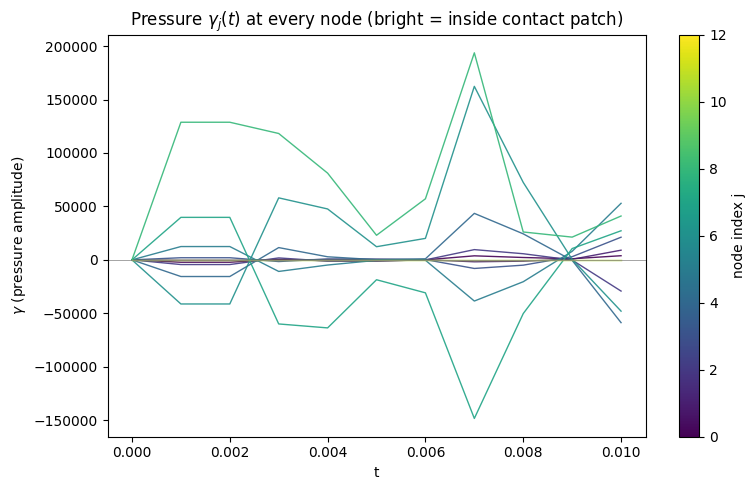

saved pressure_amplitudes.png


In [ ]:
gamma_hist = np.array([unflatten(x, N)[2] for x in all_xs_arr])   # shape (num_steps, N)

fig2, ax2 = plt.subplots(figsize=(8, 5))
cmap = plt.cm.viridis
for node in range(N):
    color = cmap(node / (N - 1))
    ax2.plot(all_ts_arr, gamma_hist[:, node], color=color, lw=1,
              alpha=0.9 if node <= 2 * I else 0.3)  # contact-zone nodes emphasized

ax2.axhline(0, color="gray", lw=0.5)
ax2.set_xlabel("t")
ax2.set_ylabel(r"$\gamma$ (pressure amplitude)")
ax2.set_title(r"Pressure $\gamma_j(t)$ at every node (bright = inside contact patch)")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, N - 1))
sm.set_array([])
cbar = fig2.colorbar(sm, ax=ax2)
cbar.set_label("node index j")

fig2.tight_layout()
fig2.savefig("pressure_amplitudes.png", dpi=150)
plt.show()
print("saved pressure_amplitudes.png")

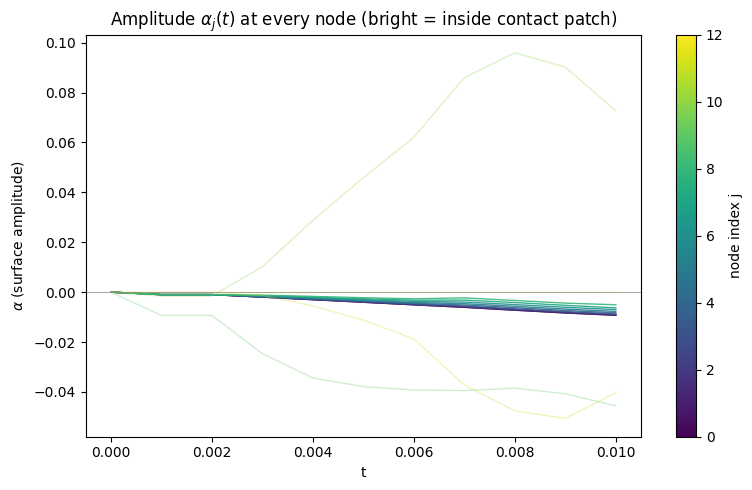

saved pressure_amplitudes.png


In [ ]:
alpha_hist = np.array([unflatten(x, N)[0] for x in all_xs_arr])   # shape (num_steps, N)

fig2, ax2 = plt.subplots(figsize=(8, 5))
cmap = plt.cm.viridis
for node in range(N):
    color = cmap(node / (N - 1))
    ax2.plot(all_ts_arr, alpha_hist[:, node], color=color, lw=1,
              alpha=0.9 if node <= 2 * I else 0.3)  # contact-zone nodes emphasized

ax2.axhline(0, color="gray", lw=0.5)
ax2.set_xlabel("t")
ax2.set_ylabel(r"$\alpha$ (surface amplitude)")
ax2.set_title(r"Amplitude $\alpha_j(t)$ at every node (bright = inside contact patch)")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, N - 1))
sm.set_array([])
cbar = fig2.colorbar(sm, ax=ax2)
cbar.set_label("node index j")

fig2.tight_layout()
fig2.savefig("pressure_amplitudes.png", dpi=150)
plt.show()
print("saved pressure_amplitudes.png")

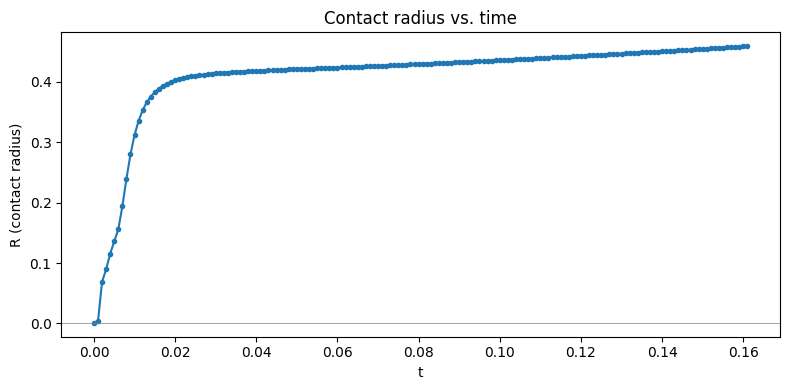

saved R_vs_time.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

R_hist = np.array([unflatten(x, N)[5] for x in all_xs])   # unflatten returns (a,b,g,h,v,R)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(all_ts, R_hist, "o-", color="tab:blue", ms=3, lw=1.5)
ax.set_xlabel("t")
ax.set_ylabel("R (contact radius)")
ax.set_title("Contact radius vs. time")
ax.axhline(0, color="gray", lw=0.5)
fig.tight_layout()
fig.savefig("R_vs_time.png", dpi=150)
plt.show()
print("saved R_vs_time.png")

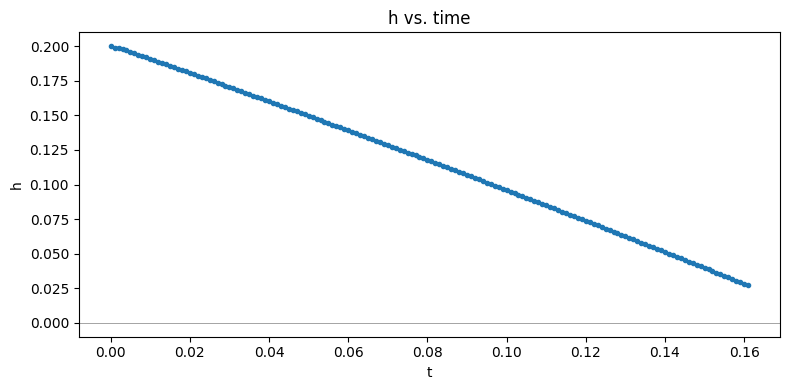

saved R_vs_time.png


In [ ]:
h_hist = np.array([unflatten(x, N)[-3] for x in all_xs])   # unflatten returns (a,b,g,h,v,R)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(all_ts, h_hist, "o-", color="tab:blue", ms=3, lw=1.5)
ax.set_xlabel("t")
ax.set_ylabel("h")
ax.set_title("h vs. time")
ax.axhline(0, color="gray", lw=0.5)
fig.tight_layout()
fig.savefig("R_vs_time.png", dpi=150)
plt.show()
print("saved R_vs_time.png")